This builds off test calculations performed in Excel which analyzed two water rights. The goal is to get monthly and/or seasonal use patterns - for example, the total (direct diversion + diversion to storage) volume each month in each year; the proportion of the average that each month represents over the reporting period; theoretical monthly water use (monthly proportion times face value); the monthly use as a percentage of the annual total, etc.

The data used in the analysis comes from the Demand Dataset Monthly Values workbook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt



In [2]:
NAVR = pd.read_csv("..\\referenceFiles\\NAVR_2017_2024_DemandDataset_MonthlyValues.csv")

# below file contains face values for the water rights
NAVR_MDT_FV = pd.read_csv("..\\referenceFiles\\NV_MDT_FV.csv")

In [ ]:
#NAVR.columns

### Begin Calculations

**\<MONTH\>_AVG** is the sum of direct diversion and diversion to storage divided by the number of years reported by that water right
* e.g., (Jan 2017 total + Jan 2018 total + ... + Jan 2024 total) / 8

#### Test the procedure on a single water right

In [ ]:
# try to loop here:
# for one right, loop to sum all Januarys and divide by the count of years
# do for all months, then join them into a single table (or would it be a vector?)

#water_right_id = "A009618"
#water_right_df = NAVR[NAVR["APPLICATION_NUMBER"] == water_right_id]

#Jan_Avg_Vol = water_right_df["JAN_TOTAL_DIVERSION"].mean()

In [ ]:
#water_right_df.head()

,APPLICATION_NUMBER,YEAR,CALENDAR_YEAR_OR_WATER_YEAR,JAN_DIRECT_DIVERSION,FEB_DIRECT_DIVERSION,MAR_DIRECT_DIVERSION,APR_DIRECT_DIVERSION,MAY_DIRECT_DIVERSION,JUN_DIRECT_DIVERSION,JUL_DIRECT_DIVERSION,...,MAR_TOTAL_DIVERSION,APR_TOTAL_DIVERSION,MAY_TOTAL_DIVERSION,JUN_TOTAL_DIVERSION,JUL_TOTAL_DIVERSION,AUG_TOTAL_DIVERSION,SEP_TOTAL_DIVERSION,OCT_TOTAL_DIVERSION,NOV_TOTAL_DIVERSION,DEC_TOTAL_DIVERSION
0,A009618,2017,CY,0.0,0.0,0.0,0.0,5.0000,10.0000,10.0000,...,0.0,0.0,5.0000,10.0000,10.0000,5.000,0.000,0.0,0.0,0.0
1,A009618,2018,CY,0.0,0.0,0.0,0.0,0.0061,0.0061,0.0020,...,0.0,0.0,0.0061,0.0061,0.0020,0.000,0.000,0.0,0.0,0.0
2,A009618,2019,CY,0.0,0.0,0.0,0.0,0.0000,0.0061,0.0061,...,0.0,0.0,0.0000,0.0061,0.0061,0.003,0.002,0.0,0.0,0.0
3,A009618,2020,CY,0.0,0.0,0.0,0.0,1.0000,0.0500,0.0000,...,0.0,0.0,1.0000,0.0500,0.0000,0.000,0.000,0.0,0.0,0.0
4,A009618,2021,CY,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0,0.0,0.0000,0.0000,0.0000,0.000,0.000,NaN,NaN,NaN


In [ ]:
#Jun_Avg_Vol = water_right_df["JUN_TOTAL_DIVERSION"].mean()

In [ ]:
# monthly averages for a single water right

# below, square brackets create a list - in this case a list of strings where the strings are column names from the NAVR csv
# used in future lines to tell pd to only look at the specified columns
#month_columns = [
#    "JAN_TOTAL_DIVERSION", "FEB_TOTAL_DIVERSION", "MAR_TOTAL_DIVERSION",
#    "APR_TOTAL_DIVERSION", "MAY_TOTAL_DIVERSION", "JUN_TOTAL_DIVERSION",
#    "JUL_TOTAL_DIVERSION", "AUG_TOTAL_DIVERSION", "SEP_TOTAL_DIVERSION",
#    "OCT_TOTAL_DIVERSION", "NOV_TOTAL_DIVERSION", "DEC_TOTAL_DIVERSION"
#]

# the list is passed inside brackets, pd returns a df containing only those columns for the specified water right. then, evaluate the mean. mean is a np function and pd calculates the mean down each column (in thise case, columns are months for each year on record)
#all_month_averages = water_right_df[month_columns].mean()
#print(all_month_averages)

NameError: name 'water_right_df' is not defined

#### Adapt the above method, applied to a single water right, and calculate monthly averages for all water rights in NAVR. This is the average total diversion per month for each water right.

In [5]:
# define the columns that will identify the water right and the value of interest (total diversion)
id_column = "APPLICATION_NUMBER"

month_columns = [
    "JAN_TOTAL_DIVERSION", "FEB_TOTAL_DIVERSION", "MAR_TOTAL_DIVERSION",
    "APR_TOTAL_DIVERSION", "MAY_TOTAL_DIVERSION", "JUN_TOTAL_DIVERSION",
    "JUL_TOTAL_DIVERSION", "AUG_TOTAL_DIVERSION", "SEP_TOTAL_DIVERSION",
    "OCT_TOTAL_DIVERSION", "NOV_TOTAL_DIVERSION", "DEC_TOTAL_DIVERSION"
]

# select the columns, group by id, determine mean
# groupby() takes advtange of Split-Apply-Combine pattern. 
# Split: pd looks at id_column, splits NAVR into smaller table for each water right
# Apply: applies function, mean() in this case, to each of the tables, calculating a mean for each month for each water right
# Combine: takes computed values and puts them back together in new df; each row is a water right, each column is the monthly average
# NAVR[[id_column] + month_columns] ensures those are the only columns that pd evaluates (rather than trying to compute mean of Application ID numbers)
all_rights_monthly_averages = (
    NAVR[[id_column] + month_columns].groupby(id_column)
    .mean()
    .reset_index() # take the index (APPLICATION_NUMBER) used in the calculation and add it back as a standard column in the all_rights_averages data frame
)
# using groupby(), pd takes id_column and effectively makes it the index of the small tables for each right created by the Split
# thus, pd knows not to try determining the mean over water right IDs
# then pd looks at remaining columns (the month_columns, which all have numeric values) using mean(), checks that they are numeric; if col has a string it is skipped, if it contains numbers it calculates the mean

#df.rename(columns={'A': 'X', 'B': 'Y'}, inplace=True)

all_rights_monthly_averages.rename(
    columns = {'JAN_TOTAL_DIVERSION': 'JAN_AVG_DIVERSION',
               'FEB_TOTAL_DIVERSION': 'FEB_AVG_DIVERSION',
               'MAR_TOTAL_DIVERSION': 'MAR_AVG_DIVERSION',
               'APR_TOTAL_DIVERSION': 'APR_AVG_DIVERSION',
               'MAY_TOTAL_DIVERSION': 'MAY_AVG_DIVERSION',
               'JUN_TOTAL_DIVERSION': 'JUN_AVG_DIVERSION',
               'JUL_TOTAL_DIVERSION': 'JUL_AVG_DIVERSION',
               'AUG_TOTAL_DIVERSION': 'AUG_AVG_DIVERSION',
               'SEP_TOTAL_DIVERSION': 'SEP_AVG_DIVERSION',
               'OCT_TOTAL_DIVERSION': 'OCT_AVG_DIVERSION',
               'NOV_TOTAL_DIVERSION': 'NOV_AVG_DIVERSION',
               'DEC_TOTAL_DIVERSION': 'DEC_AVG_DIVERSION'},
               inplace = True
)
print(all_rights_monthly_averages.head()) # each row is a water right, each column is the average volume for that month

# merge data frames based on common application number
NAVR = pd.merge(NAVR, all_rights_monthly_averages, on = "APPLICATION_NUMBER", how = "left")

  APPLICATION_NUMBER  JAN_AVG_DIVERSION  FEB_AVG_DIVERSION  MAR_AVG_DIVERSION  \
0            A009618           0.000000           0.000000           0.000000   
1            A012489           0.000000           0.000000           0.000000   
2            A013176           0.000000           0.000000           0.000000   
3            A015098           0.351986           0.383393           0.333145   
4           A015425A           0.000000           0.000000           0.000000   

   APR_AVG_DIVERSION  MAY_AVG_DIVERSION  JUN_AVG_DIVERSION  JUL_AVG_DIVERSION  \
0           0.000000           1.175763           2.020275           1.551013   
1           0.000000           0.020459           0.020459           0.020459   
2           0.000000           0.000000           0.000000           0.000000   
3           0.203321           0.288411           0.284195           0.335327   
4           0.000000           0.988384           0.923968           0.970508   

   AUG_AVG_DIVERSION  SEP_

Calculate the annual total for each year reported by each water right. 

In [7]:
# define column names
id_column = "APPLICATION_NUMBER"
year_column = "YEAR"

# group by application and year, then find the sum
annual_totals = (
    NAVR[[id_column, year_column] + month_columns]
    .groupby([id_column, year_column])
    .sum()
)

# add months together horizontally (axis = 1) to create annual total value
annual_totals["Annual_Sum"] = annual_totals[month_columns].sum(axis = 1)

# drop the columns with monthly data, reset index so APPLICATION_NUMBER and YEAR are regular columns
# groupby() turns the grouping columns into an index. reset_index() converts them back into usable data columns to view/export
annual_totals = annual_totals[["Annual_Sum"]].reset_index()

print(annual_totals.head())

# merge with NAVR
# they have APPLICATION_NUMBER and YEAR columns in common; perform the merge on both columns using a list
# using list ensures pandas aligns rows only when both the application number and year match
NAVR = pd.merge(NAVR, annual_totals, on = ["APPLICATION_NUMBER", "YEAR"], how = "left")

  APPLICATION_NUMBER  YEAR  Annual_Sum
0            A009618  2017     30.0000
1            A009618  2018      0.0142
2            A009618  2019      0.0172
3            A009618  2020      1.0500
4            A009618  2021      0.0000


Then calculate the average of `annual_totals` for each water right. (`annual_totals` divided by the number of years reported)

In [8]:
# define the columns that will identify the water right and the value of interest (total diversion)
id_column = "APPLICATION_NUMBER"

# select the columns, group by id, determine mean
# groupby() takes advtange of Split-Apply-Combine pattern. 
# Split: pd looks at id_column, splits annual_averages into smaller table for each water right
# Apply: applies function, mean() in this case, to each of the tables, calculating a mean annual sum for each water right
# Combine: takes computed values and puts them back together in new df; each row is a water right, with columns for the APPLICATION_NUMBER and Annual_Average
# NAVR[[id_column] + month_columns] ensures those are the only columns that pd evaluates
annual_averages = (
    annual_totals.groupby(id_column, as_index = False)["Annual_Sum"].mean()
    .rename(columns = {"Annual_Sum": "Annual_Average"})
)
# using groupby(), pd takes id_column and effectively makes it the index of the small tables for each right created by the Split
# thus, pd knows not to try determining the mean over water right IDs
# then pd looks at remaining columns (the month_columns, which all have numeric values) using mean(), checks that they are numeric; if col has a string it is skipped, if it contains numbers it calculates the mean
print(annual_averages.head())

NAVR = pd.merge(NAVR, annual_averages, on = "APPLICATION_NUMBER", how = "left")


  APPLICATION_NUMBER  Annual_Average
0            A009618        5.372675
1            A012489        0.143215
2            A013176        0.000000
3            A015098        3.243491
4           A015425A        3.370209


### Proportions

Monthly proportions for each year on record for each water right.

In [9]:
# merge the NAVR df and NAVR_MDT_FV df (the latter has the face values)
# bring FACE_VALUE_AMOUNT_AF from NAVR_MDT_FV into NAVR df, creating a new df. Face values are correctly placed by matching APPLICATION_NUMBER, and original rows are unchanged w/ "left"

NAVR = pd.merge(
    NAVR,
    NAVR_MDT_FV[["APPLICATION_NUMBER", "FACE_VALUE_AMOUNT_AF"]], # two square brackets, [[ ]], selects a list of columns from NAVR_MDT_FV
    on = "APPLICATION_NUMBER", # pandas looks for this in both data frames and uses it as the identifier to match rows together
    how = "left" # ensures all rows from NAVR are retained. pandas searches NAVR_MDT_FV for matching APPLICATION_NUMBER and appends the FACE_VALUE_AMOUNT_AF
)

#NAVR.columns

In [10]:
# monthly use as a proportion of the face value

# select the columns of monthly data: NAVR[month_columns]
# everything w/in .div(): divide the month columns by the FACE_VALUE_AMOUNT_AF column going row-by-row; axis = 0 aligns things by their row positions
all_rights_monthly_proportion = NAVR[month_columns].div(
    NAVR["FACE_VALUE_AMOUNT_AF"],
    axis = 0
)

# inserts APPLICATION_NUMBER at beginning of new all_rights_monthly_proportion data frame (0 is the column index)
all_rights_monthly_proportion.insert(0, "APPLICATION_NUMBER", NAVR["APPLICATION_NUMBER"])

# inserts YEAR next to APPLICATION_NUMBER in the new data frame
all_rights_monthly_proportion.insert(1, "YEAR", NAVR["YEAR"])

all_rights_monthly_proportion = all_rights_monthly_proportion.rename(columns = {
    "JAN_TOTAL_DIVERSION": "JAN_PROPORTION",
    "FEB_TOTAL_DIVERSION": "FEB_PROPORTION",
    "MAR_TOTAL_DIVERSION": "MAR_PROPORTION",
    "APR_TOTAL_DIVERSION": "APR_PROPORTION",
    "MAY_TOTAL_DIVERSION": "MAY_PROPORTION",
    "JUN_TOTAL_DIVERSION": "JUN_PROPORTION",
    "JUL_TOTAL_DIVERSION": "JUL_PROPORTION",
    "AUG_TOTAL_DIVERSION": "AUG_PROPORTION",
    "SEP_TOTAL_DIVERSION": "SEP_PROPORTION",
    "OCT_TOTAL_DIVERSION": "OCT_PROPORTION",
    "NOV_TOTAL_DIVERSION": "NOV_PROPORTION",
    "DEC_TOTAL_DIVERSION": "DEC_PROPORTION"
})

print(all_rights_monthly_proportion.head())

NAVR = pd.merge(NAVR, all_rights_monthly_proportion, on = ["APPLICATION_NUMBER", "YEAR"], how = "left")

  APPLICATION_NUMBER  YEAR  JAN_PROPORTION  FEB_PROPORTION  MAR_PROPORTION  \
0            A009618  2017             0.0             0.0             0.0   
1            A009618  2018             0.0             0.0             0.0   
2            A009618  2019             0.0             0.0             0.0   
3            A009618  2020             0.0             0.0             0.0   
4            A009618  2021             0.0             0.0             0.0   

   APR_PROPORTION  MAY_PROPORTION  JUN_PROPORTION  JUL_PROPORTION  \
0             0.0        0.100000        0.200000        0.200000   
1             0.0        0.000122        0.000122        0.000040   
2             0.0        0.000000        0.000122        0.000122   
3             0.0        0.020000        0.001000        0.000000   
4             0.0        0.000000        0.000000        0.000000   

   AUG_PROPORTION  SEP_PROPORTION  OCT_PROPORTION  NOV_PROPORTION  \
0         0.10000         0.00000             0

Average monthly proportion for the period of record for each water right.

In [11]:
month_columns = [
    "JAN_PROPORTION", "FEB_PROPORTION", "MAR_PROPORTION",
    "APR_PROPORTION", "MAY_PROPORTION", "JUN_PROPORTION",
    "JUL_PROPORTION", "AUG_PROPORTION", "SEP_PROPORTION",
    "OCT_PROPORTION", "NOV_PROPORTION", "DEC_PROPORTION"
]

average_monthly_proportion = (
    all_rights_monthly_proportion.groupby("APPLICATION_NUMBER")[month_columns]
    .mean()
    .reset_index()
)

average_monthly_proportion = average_monthly_proportion.rename(columns = {
    "JAN_PROPORTION": "JAN_AVG_PROPORTION",
    "FEB_PROPORTION": "FEB_AVG_PROPORTION",
    "MAR_PROPORTION": "MAR_AVG_PROPORTION",
    "APR_PROPORTION": "APR_AVG_PROPORTION",
    "MAY_PROPORTION": "MAY_AVG_PROPORTION",
    "JUN_PROPORTION": "JUN_AVG_PROPORTION",
    "JUL_PROPORTION": "JUL_AVG_PROPORTION",
    "AUG_PROPORTION": "AUG_AVG_PROPORTION",
    "SEP_PROPORTION": "SEP_AVG_PROPORTION",
    "OCT_PROPORTION": "OCT_AVG_PROPORTION",
    "NOV_PROPORTION": "NOV_AVG_PROPORTION",
    "DEC_PROPORTION": "DEC_AVG_PROPORTION"
})

print(average_monthly_proportion.head())

NAVR = pd.merge(NAVR, average_monthly_proportion, on = "APPLICATION_NUMBER", how = "left")

  APPLICATION_NUMBER  JAN_AVG_PROPORTION  FEB_AVG_PROPORTION  \
0            A009618            0.000000            0.000000   
1            A012489            0.000000            0.000000   
2            A013176            0.000000            0.000000   
3            A015098            0.065183            0.070999   
4           A015425A            0.000000            0.000000   

   MAR_AVG_PROPORTION  APR_AVG_PROPORTION  MAY_AVG_PROPORTION  \
0            0.000000            0.000000            0.023515   
1            0.000000            0.000000            0.000429   
2            0.000000            0.000000            0.000000   
3            0.061693            0.037652            0.053409   
4            0.000000            0.000000            0.044927   

   JUN_AVG_PROPORTION  JUL_AVG_PROPORTION  AUG_AVG_PROPORTION  \
0            0.040406            0.031020            0.012508   
1            0.000429            0.000429            0.000429   
2            0.000000        

### Potential Monthly Volumes Based on Proportions

For each water right: \<month\>_avg_proportion x Face_Value

In [12]:
avg_prop_columns = [
    "JAN_AVG_PROPORTION", "FEB_AVG_PROPORTION", "MAR_AVG_PROPORTION",
    "APR_AVG_PROPORTION", "MAY_AVG_PROPORTION", "JUN_AVG_PROPORTION",
    "JUL_AVG_PROPORTION", "AUG_AVG_PROPORTION", "SEP_AVG_PROPORTION",
    "OCT_AVG_PROPORTION", "NOV_AVG_PROPORTION", "DEC_AVG_PROPORTION"
]

# define columns to hold the calculated monthly proportional volumes
vol_columns = [
    "JAN_PROP_VOL", "FEB_PROP_VOL", "MAR_PROP_VOL",
    "APR_PROP_VOL", "MAY_PROP_VOL", "JUN_PROP_VOL",
    "JUL_PROP_VOL", "AUG_PROP_VOL", "SEP_PROP_VOL",
    "OCT_PROP_VOL", "NOV_PROP_VOL", "DEC_PROP_VOL"
]

# calculate then add the columns to NAVR
for prop_col, vol_col in zip(avg_prop_columns, vol_columns):
    NAVR[vol_col] = NAVR["FACE_VALUE_AMOUNT_AF"] * NAVR[prop_col]

# verify calculation worked
print(NAVR[["APPLICATION_NUMBER", "FACE_VALUE_AMOUNT_AF", "JAN_AVG_PROPORTION", "JAN_PROP_VOL"]].head())

  APPLICATION_NUMBER  FACE_VALUE_AMOUNT_AF  JAN_AVG_PROPORTION  JAN_PROP_VOL
0            A009618                  50.0                 0.0           0.0
1            A009618                  50.0                 0.0           0.0
2            A009618                  50.0                 0.0           0.0
3            A009618                  50.0                 0.0           0.0
4            A009618                  50.0                 0.0           0.0


### Export data frames

Use outputs in creating Power BI dashboard

In [13]:
NAVR.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_final_table.csv", index = False)

#all_rights_averages.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_all_rights_averages.csv", index = False)

#annual_totals.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_annual_totals.csv", index = False)

#annual_averages.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_annual_averages.csv", index = False)

#all_rights_monthly_proportion.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_all_rights_monthly_proportion.csv", index = False)

#average_monthly_proportion.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_average_monthly_proportion.csv", index = False)

#monthly_volumes.to_csv("..\\Outputs\\Demand_Analysis_Tables\\NAVR_monthly_volumes.csv", index = False)

### Plotting

In [ ]:
# best way to plot? seems challenging since there are 246 rows; that would be overwhelming on a single graph.

In [11]:
print(monthly_volumes.columns) 
print(monthly_volumes.head())
# the columns are <month>_avg_proportion but the values are the average volume

Index(['JAN_AVG_PROPORTION', 'FEB_AVG_PROPORTION', 'MAR_AVG_PROPORTION',
       'APR_AVG_PROPORTION', 'MAY_AVG_PROPORTION', 'JUN_AVG_PROPORTION',
       'JUL_AVG_PROPORTION', 'AUG_AVG_PROPORTION', 'SEP_AVG_PROPORTION',
       'OCT_AVG_PROPORTION', 'NOV_AVG_PROPORTION', 'DEC_AVG_PROPORTION'],
      dtype='str')
                    JAN_AVG_PROPORTION  FEB_AVG_PROPORTION  \
APPLICATION_NUMBER                                           
A009618                       0.000000            0.000000   
A012489                       0.000000            0.000000   
A013176                       0.000000            0.000000   
A015098                       0.351986            0.383393   
A015425A                      0.000000            0.000000   

                    MAR_AVG_PROPORTION  APR_AVG_PROPORTION  \
APPLICATION_NUMBER                                           
A009618                       0.000000            0.000000   
A012489                       0.000000            0.000000   
A0131

ValueError: The condensed distance matrix must contain only finite values.

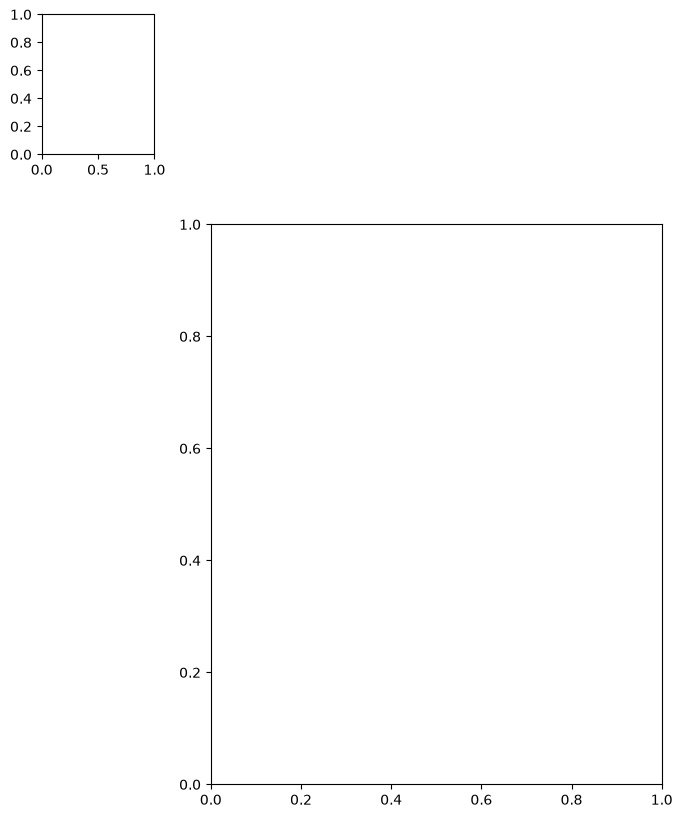

In [12]:
import seaborn as sns
import scipy

sns.clustermap(
    monthly_volumes[month_columns],
    cmap = "YlGnBu",
    standard_scale = 1, # normalizes the scale to shapes are comparable
    figsize = (8, 10),
    row_cluster = True, # groups similar water rights together
    col_cluster = False # keeps months in chronological order
)

plt.show()